In [1]:
import json
import os
from pathlib import Path
from pprint import pprint
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

dirpath_repo_root = Path().resolve().parents[2]
dirpath_self = Path().resolve().parent
sys.path.append(str(dirpath_repo_root))
sys.path.append(str(dirpath_self))

from analysis.ou_tuning import batch_utils

In [2]:
def _get_fpath_by_templ(dirpath: Path, fname_templ: str) -> str:
    files = list(dirpath.glob(fname_templ))
    if len(files) != 1:
        print(f'Path for search: {str(dirpath)}')
        print(f'Name template: {fname_templ}')
        raise RuntimeError('Should be exactly one filename match')
    return files[0]

In [3]:
exp_name = 'batch_rxbkg_state1_mech1/net_newsec_ee_fade_var_rpop'
exp_name_sub = 'exp_ctx_ee_fade_frz_SOM2_0.1_10_VIP2_0.1_25_npts_10_t_7.0_10.0_wmult_0.25_ee_0.5'

dirpath_cfg = dirpath_repo_root / 'exp_configs' / exp_name
dirpath_res = dirpath_repo_root / 'exp_results' / exp_name

fname_data_templ = 'result_{job:05d}_*.json'

# Extract (param_grid -> job_id) xarray from cfg folder
job_idx_xr = batch_utils.extract_batch_params_to_xr(
    dirpath_res / exp_name_sub / 'cfg',
    cfg_param_fields={'pop_frz': 'pop_frz', 'rate_pt': 'rate_pt'},
    fname_cfg_templ='cfg_*.json',
    job_pos_in_fname=1
)
job_idx_xr

<xarray.DataArray 'job_id' (pop_frz: 2, rate_pt: 10)> Size: 160B
array([[ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18],
       [ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]])
Coordinates:
  * pop_frz  (pop_frz) object 16B 'SOM2' 'VIP2'
  * rate_pt  (rate_pt) int64 80B 0 1 2 3 4 5 6 7 8 9

In [4]:
# Load target firing rates
fpath_target = dirpath_cfg / 'target_state_1.csv'
df = pd.read_csv(fpath_target)
df = df.set_index('pop_name')
target_rates = df.to_dict()['target_rate']
target_rates

{'NGF1': 3.0,
 'IT2': 2.0,
 'PV2': 12.0,
 'SOM2': 6.0,
 'VIP2': 7.0,
 'NGF2': 1.0,
 'IT3': 2.0,
 'PV3': 12.0,
 'SOM3': 6.0,
 'VIP3': 7.0,
 'NGF3': 1.0,
 'ITS4': 2.0,
 'ITP4': 2.0,
 'PV4': 10.0,
 'SOM4': 5.0,
 'VIP4': 0.2,
 'NGF4': 0.1,
 'IT5A': 5.0,
 'CT5A': 2.0,
 'PV5A': 8.0,
 'SOM5A': 4.0,
 'VIP5A': 0.2,
 'NGF5A': 0.5,
 'IT5B': 5.0,
 'CT5B': 2.0,
 'PT5B': 5.0,
 'PV5B': 8.0,
 'SOM5B': 4.0,
 'VIP5B': 0.2,
 'NGF5B': 0.5,
 'IT6': 3.0,
 'CT6': 2.0,
 'PV6': 15.0,
 'SOM6': 7.0,
 'VIP6': 0.2,
 'NGF6': 0.5,
 'TC': 8.0,
 'HTC': 8.0,
 'TCM': 2.0,
 'TI': 15.0,
 'TIM': 10.0,
 'IRE': 15.0,
 'IREM': 10.0}

In [5]:
n_rate_pts = job_idx_xr.sizes['rate_pt']
rates_frz = {}

for pop_frz in job_idx_xr.coords['pop_frz'].values:
    rates_frz[pop_frz] = np.zeros(n_rate_pts)
    for rate_pt in job_idx_xr.coords['rate_pt'].values:
        job_id = job_idx_xr.sel(pop_frz=pop_frz, rate_pt=rate_pt)
        if np.isnan(job_id):
            continue
        fname_cfg = 'cfg_{job:05d}_*.json'.format(job=int(job_id))
        fpath_cfg = _get_fpath_by_templ(
            dirpath_res / exp_name_sub / 'cfg', fname_cfg)
        with open(fpath_cfg, 'r') as fid:
            cfg = json.load(fid)
        rates_frz[pop_frz][rate_pt] = (
            cfg['simConfig']['subnet_params']['frozen_rates_custom'][pop_frz]
        )
        #print(pop_frz, rate_pt, rates_frz[pop_frz][rate_pt])
rates_frz

{'SOM2': array([ 0.1,  1.2,  2.3,  3.4,  4.5,  5.6,  6.7,  7.8,  8.9, 10. ]),
 'VIP2': array([ 0.1,  2.9,  5.6,  8.4, 11.2, 13.9, 16.7, 19.5, 22.2, 25. ])}

In [6]:
PYR_POPS = ['IT2', 'IT3', 'ITP4', 'ITS4', 'IT5A', 'IT5B', 'IT6',
            'CT5A', 'CT5B', 'CT6', 'PT5B']
PV_POPS = ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6']
SOM_POPS = ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6']
VIP_POPS = ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6']
NGF_POPS = ['NGF1', 'NGF2', 'NGF3', 'NGF4', 'NGF5A', 'NGF5B', 'NGF6']

In [7]:
#pops_used = ['IT2', 'PV2', 'SOM2', 'VIP2', 'NGF2']
pops_used = PYR_POPS + PV_POPS + SOM_POPS + VIP_POPS + NGF_POPS

R_all = {}
for pop_frz, rates_frz_ in rates_frz.items():
    R_all[pop_frz] = xr.DataArray(
        np.full((len(pops_used), len(rates_frz_)), np.nan),
        dims=('pop', 'rate_frz'),
        coords={'pop': pops_used, 'rate_frz': rates_frz_},
    )
R_all

{'SOM2': <xarray.DataArray (pop: 36, rate_frz: 10)> Size: 3kB
 array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan,

In [8]:
for pop_frz in job_idx_xr.coords['pop_frz'].values:
    for rate_pt in job_idx_xr.coords['rate_pt'].values:
        r_frz = rates_frz[pop_frz][rate_pt]
        job_id = job_idx_xr.sel(pop_frz=pop_frz, rate_pt=rate_pt)
        if np.isnan(job_id):
            continue
        fname_res = 'result_{job:05d}_*.json'.format(job=int(job_id))
        fpath_res = _get_fpath_by_templ(
            dirpath_res / exp_name_sub / 'results', fname_res)
        with open(fpath_res, 'r') as fid:
            res = json.load(fid)
        for pop in pops_used:
            pop_src = f'{pop}frz' if pop == pop_frz else pop
            #print(pop_frz, rate_pt, pop, pop_src, r_frz)
            R_all[pop_frz].loc[{'pop': pop, 'rate_frz': r_frz}] = (
                res['rates'][pop_src]
            )
R_all

{'SOM2': <xarray.DataArray (pop: 36, rate_frz: 10)> Size: 3kB
 array([[ 1.72682446,  1.79783037,  1.75936884,  1.68934911,  1.74063116,
          1.7642998 ,  1.71597633,  1.76035503,  1.79289941,  1.79684418],
        [ 2.02047374,  2.01905402,  2.01890458,  2.02331316,  2.01920347,
          2.01770903,  2.02226706,  2.01995068,  2.02211761,  2.0179332 ],
        [ 1.97889287,  1.97769813,  1.96694544,  1.98088411,  1.97809638,
          1.97451215,  1.96375946,  1.96057348,  1.95181203,  1.96057348],
        [ 2.00278773,  2.00119474,  1.99561928,  2.00278773,  1.98805257,
          1.99322979,  1.98845082,  1.98407009,  1.98088411,  1.99322979],
        [ 4.95078923,  4.92200557,  4.92943361,  4.93779016,  4.9266481 ,
          4.93407614,  4.90622098,  4.95543175,  4.84586815,  4.85236769],
        [ 5.06723284,  5.03609342,  5.03467799,  5.09483369,  5.0552017 ,
          5.04317056,  5.07006369,  5.04600142,  5.00070771,  5.00707714],
        [ 2.99405352,  2.99471424,  3.001321

In [9]:
from scipy.interpolate import splprep, splev
from sklearn.manifold import Isomap
from scipy.interpolate import PchipInterpolator

def smooth_curve(rx, ry, s=0.0):
    pts = np.column_stack([rx, ry]).astype(float)

    # remove consecutive duplicates
    d = np.sqrt(np.sum(np.diff(pts, axis=0)**2, axis=1))
    keep = np.r_[True, d > 0]
    pts = pts[keep]

    if len(pts) < 2:
        return pts[:, 0], pts[:, 1]

    # chord-length parameter
    d = np.sqrt(np.sum(np.diff(pts, axis=0)**2, axis=1))
    u = np.r_[0, np.cumsum(d)]

    k = min(3, len(pts) - 1)
    tck, _ = splprep([pts[:, 0], pts[:, 1]], u=u, s=s, k=k)
    u_fine = np.linspace(u[0], u[-1], 200)
    x_smooth, y_smooth = splev(u_fine, tck)
    return x_smooth, y_smooth

import numpy as np
from sklearn.manifold import Isomap
from scipy.interpolate import UnivariateSpline

def smooth_curve_2d(rx, ry, n_neighbors=None, smooth=0.1, n=200):
    x = np.asarray(rx, float)
    y = np.asarray(ry, float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    pts = np.column_stack([x, y])

    if len(pts) < 2:
        return x, y

    # remove exact duplicates
    _, idx = np.unique(pts, axis=0, return_index=True)
    pts = pts[np.sort(idx)]
    m = len(pts)

    if m < 2:
        return pts[:, 0], pts[:, 1]

    if n_neighbors is None:
        n_neighbors = min(max(3, m // 2), m - 1)

    u = Isomap(n_neighbors=n_neighbors, n_components=1).fit_transform(pts).ravel()

    idx = np.argsort(u)
    u = u[idx]
    x = pts[idx, 0]
    y = pts[idx, 1]

    keep = np.r_[True, np.diff(u) > 1e-12]
    u, x, y = u[keep], x[keep], y[keep]

    if len(u) < 2:
        return x, y

    # scale-invariant-ish choice
    s = smooth * len(u)

    k = min(3, len(u) - 1)
    fx = UnivariateSpline(u, x, s=s, k=k)
    fy = UnivariateSpline(u, y, s=s, k=k)

    u_fine = np.linspace(u[0], u[-1], n)
    return fx(u_fine), fy(u_fine)

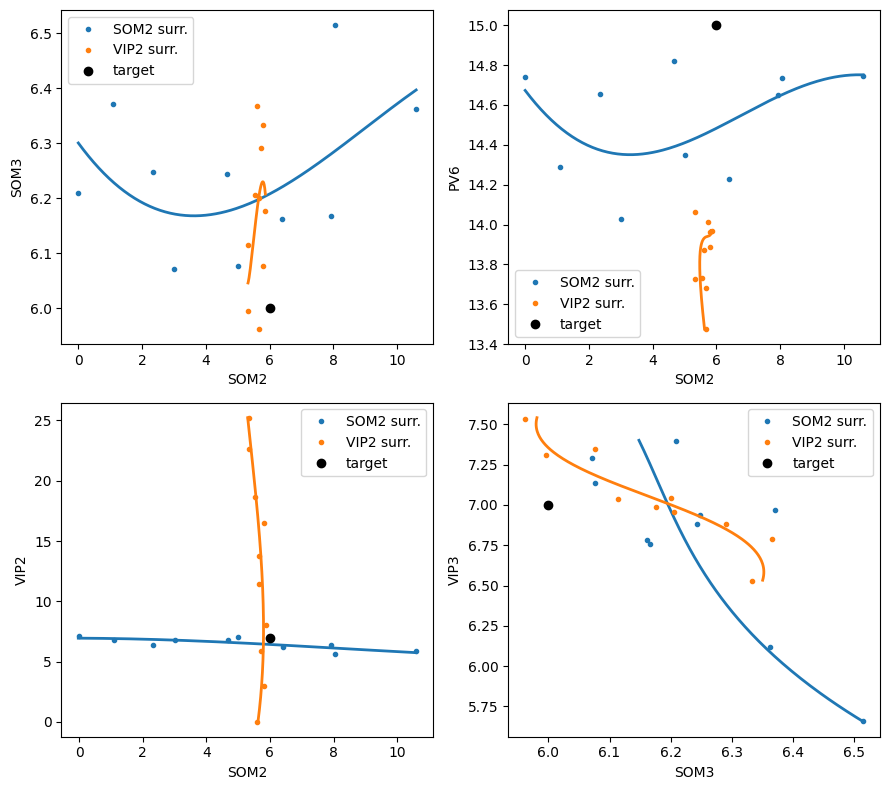

In [10]:
from scipy.interpolate import UnivariateSpline

smooth_factor = 5

pops_vis = [('SOM2', 'SOM3'), ('SOM2', 'PV6'),
            ('SOM2', 'VIP2'), ('SOM3', 'VIP3')]

plt.figure(figsize=(9, 8))
for n, pops_vis_ in enumerate(pops_vis):
    plt.subplot(2, 2, n + 1)
    for pop_frz, R in R_all.items():
        rx, ry = (R.sel(pop=pops_vis_[k]).values for k in (0, 1))

        #x_smooth, y_smooth = smooth_curve(rx, ry, s=smooth_factor)
        x_smooth, y_smooth = smooth_curve_2d(rx, ry, n_neighbors=3, smooth=0.1)

        """ # Stack into 2D array and project onto first PC (symmetric treatment)
        #pts = np.column_stack([rx, ry])
        pts = np.column_stack([rx, ry])
        pts_centered = pts - pts.mean(axis=0)
        _, _, Vt = np.linalg.svd(pts_centered, full_matrices=False)
        pc1 = Vt[0]  # First principal component direction

        # Project points onto PC1 to get a 1D ordering parameter
        t = pts_centered @ pc1
        sort_idx = np.argsort(t)
        t_sorted = t[sort_idx]
        pts_sorted = pts[sort_idx]

        # Fit smoothing splines for x and y as functions of t
        spl_x = UnivariateSpline(t_sorted, pts_sorted[:, 0], s=smooth_factor)
        spl_y = UnivariateSpline(t_sorted, pts_sorted[:, 1], s=smooth_factor)

        t_fine = np.linspace(t_sorted[0], t_sorted[-1], 200)
        x_smooth = spl_x(t_fine)
        y_smooth = spl_y(t_fine) """

        color = plt.gca()._get_lines.get_next_color()
        plt.plot(rx, ry, '.', color=color, label=f'{pop_frz} surr.')
        plt.plot(x_smooth, y_smooth, '-', color=color, linewidth=2)

    # Add target firing rates as a star marker
    tx = target_rates[pops_vis_[0]]
    ty = target_rates[pops_vis_[1]]
    plt.plot(tx, ty, '.', color='black', markersize=12, label='target', zorder=5)

    plt.xlabel(pops_vis_[0])
    plt.ylabel(pops_vis_[1])
    plt.legend()

plt.tight_layout()
plt.show()